# Customer Churn EDA - Personal Notebook

I made this as a separate EDA notebook so everyone can work in their own file without creating GitHub conflicts.

**How this notebook is structured:**
- Imports are kept in one cell at the top.
- Each analysis cell loads `train.csv` again and creates the variables it needs by itself.
- Because of that, the analysis cells can be run independently after the import cell.
- The notebook looks for data in `../data/train.csv` or `data/train.csv`, depending on where the kernel is running from.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sns.set_theme(style="whitegrid", palette="Set2")


## 1. Quick Data Check

Before doing any analysis, I want to make sure the file is loaded correctly. This part checks the dataset shape, the possible ID column, the target column, and the data type of each feature.

The main things to watch are `Churn`, `tenure`, `MonthlyCharges`, and `TotalCharges`. If a column that should be numeric is stored as text, it may need cleaning before we use it for plots or modeling.


In [2]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
id_like_cols = [col for col in train.columns if col.lower() in {"id", "customerid", "customer_id"}]

overview = pd.DataFrame({
    "metric": ["data_path", "rows", "columns", "target_col", "id_like_cols"],
    "value": [str(train_path), train.shape[0], train.shape[1], target_col, ", ".join(id_like_cols) or "Not detected"]
})
display(overview)
display(train.head())

schema = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str).values,
    "non_null": train.notna().sum().values,
    "missing": train.isna().sum().values,
    "n_unique": train.nunique(dropna=True).values
})
display(schema)


,metric,value
0,data_path,../data/train.csv
1,rows,594194
2,columns,21
3,target_col,Churn
4,id_like_cols,id


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


,column,dtype,non_null,missing,n_unique
0,id,int64,594194,0,594194
1,gender,str,594194,0,2
2,SeniorCitizen,int64,594194,0,2
3,Partner,str,594194,0,2
4,Dependents,str,594194,0,2
5,tenure,int64,594194,0,72
6,PhoneService,str,594194,0,2
7,MultipleLines,str,594194,0,3
8,InternetService,str,594194,0,3
9,OnlineSecurity,str,594194,0,3


## 2. Target Distribution: `Churn`

The first thing I want to know is how balanced the target is. In churn problems, the number of customers who leave is usually much smaller than the number of customers who stay.

This matters because accuracy can look good even when the model is not useful. If the classes are imbalanced, ROC-AUC is usually a better metric because it focuses more on ranking churn risk.


,Churn,count,percent
0,No,460377,77.479241
1,Yes,133817,22.520759


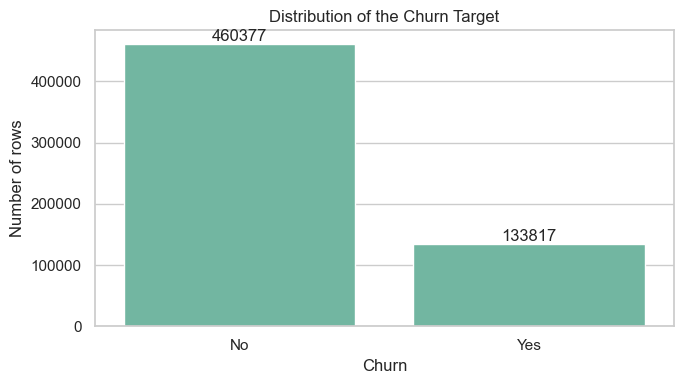

Estimated churn rate: 22.52%


In [3]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]

target_raw = train[target_col]
target_counts = target_raw.value_counts(dropna=False).rename_axis(target_col).reset_index(name="count")
target_counts["percent"] = target_counts["count"] / len(train) * 100
display(target_counts)

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=target_counts, x=target_col, y="count")
ax.set_title("Distribution of the Churn Target")
ax.set_xlabel(target_col)
ax.set_ylabel("Number of rows")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
plt.show()

target_numeric = target_raw.astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.notna().any():
    print(f"Estimated churn rate: {target_numeric.mean():.2%}")


## 3. Missing Values and Duplicates

Before trusting the charts, I need to check whether the dataset has missing values, strange data types, or duplicated rows. These issues can quietly affect the analysis later.

I also check whether billing columns such as `TotalCharges` can be converted to numbers. If many values fail conversion, that column probably needs cleaning before modeling. Duplicates are not removed here; they are only counted so we can decide what to do later.


In [4]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
id_like_cols = [col for col in train.columns if col.lower() in {"id", "customerid", "customer_id"}]
dedup_cols = [col for col in train.columns if col not in id_like_cols]

quality = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing_count": train.isna().sum(),
    "missing_pct": train.isna().mean() * 100,
    "n_unique": train.nunique(dropna=True)
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])
display(quality)

if dedup_cols:
    duplicate_count = train.duplicated(subset=dedup_cols).sum()
    print(f"Number of duplicated rows after ignoring ID columns: {duplicate_count:,}")

money_like_cols = [col for col in ["MonthlyCharges", "TotalCharges"] if col in train.columns]
for col in money_like_cols:
    converted = pd.to_numeric(train[col], errors="coerce")
    print(f"{col}: original dtype = {train[col].dtype}, values that cannot be converted to numeric = {converted.isna().sum():,}")


,dtype,missing_count,missing_pct,n_unique
id,int64,0,0.0,594194
TotalCharges,float64,0,0.0,31910
MonthlyCharges,float64,0,0.0,1921
tenure,int64,0,0.0,72
PaymentMethod,str,0,0.0,4
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3
OnlineBackup,str,0,0.0,3
DeviceProtection,str,0,0.0,3


Number of duplicated rows after ignoring ID columns: 0
MonthlyCharges: original dtype = float64, values that cannot be converted to numeric = 0
TotalCharges: original dtype = float64, values that cannot be converted to numeric = 0


## 4. Numeric Features

The numeric columns are useful for spotting broad patterns. For this dataset, I especially care about `tenure`, `MonthlyCharges`, and `TotalCharges` because they describe how long a customer has stayed and how much they pay.

I am mainly looking for distribution shifts between churn and non-churn customers. For example, if churned customers are more concentrated at low tenure or high monthly charges, that feature is probably worth keeping for modeling.


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.0,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.0,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.8,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.8,8684.80


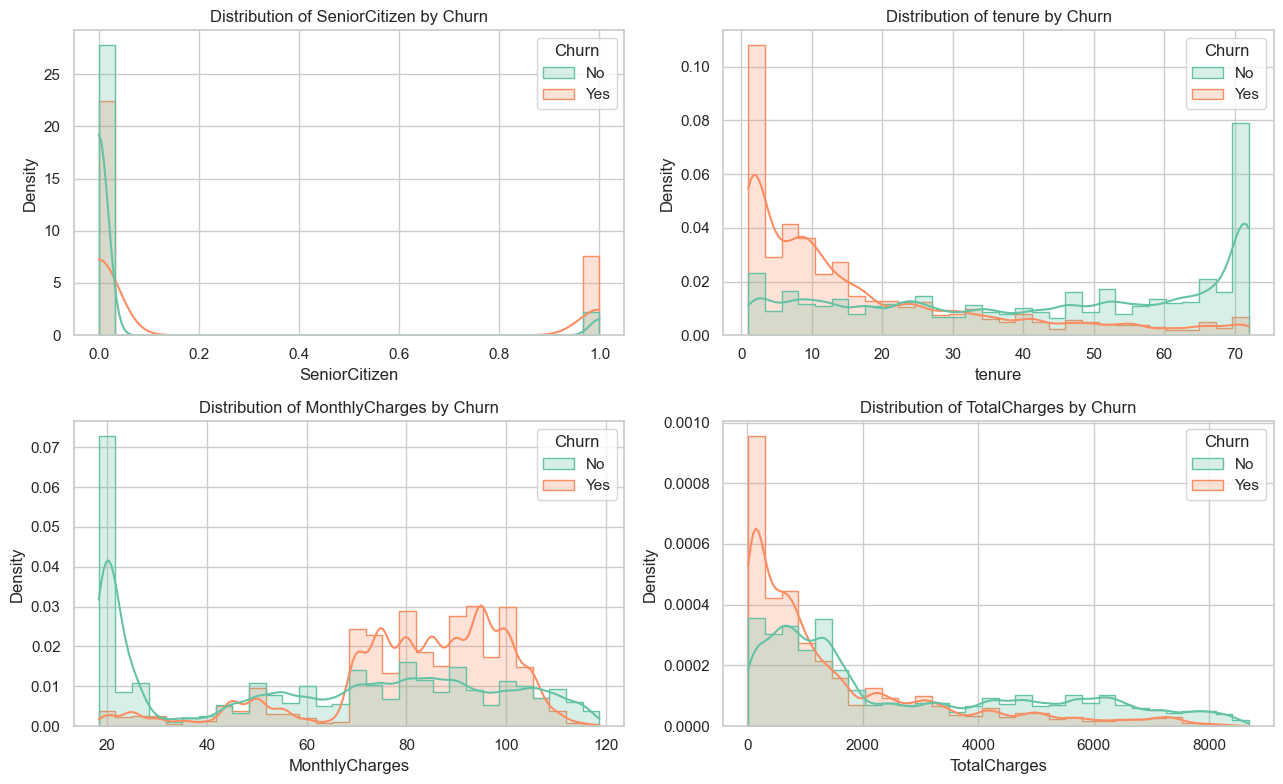

In [5]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
id_like_cols = [col for col in train.columns if col.lower() in {"id", "customerid", "customer_id"}]

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")

numeric_cols = [col for col in train.select_dtypes(include=np.number).columns if col not in id_like_cols + [target_col]]
selected_cols = numeric_cols[:8]
if not selected_cols:
    raise ValueError("No numeric features were found for analysis.")

display(train[selected_cols].describe().T)

n_cols = 2
n_rows = int(np.ceil(len(selected_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, selected_cols):
    sns.histplot(data=train, x=col, hue=target_col, kde=True, bins=30, element="step", stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {col} by {target_col}")
for ax in axes[len(selected_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


## 5. Categorical Features by Churn Rate

Many churn signals are hidden in categorical features, such as contract type, internet service, payment method, and add-on services. Instead of using averages, I compare the churn rate inside each category.

A feature is more interesting when its categories have very different churn rates. I still need to look at `count`, though, because a small category can look extreme just because it has very few rows.


,feature,category,count,churn_rate
32,Contract,Month-to-month,298918,0.420543
33,Contract,One year,108333,0.057628
34,Contract,Two year,186943,0.009982
4,Dependents,No,414362,0.291354
5,Dependents,Yes,179832,0.072796
20,DeviceProtection,No,247377,0.380630
22,DeviceProtection,Yes,206090,0.182658
21,DeviceProtection,No internet service,140727,0.014311
12,InternetService,Fiber optic,272386,0.415366
11,InternetService,DSL,181081,0.103064


,feature,n_category,min_churn_rate,max_churn_rate,rate_gap
14,PaymentMethod,4,0.069332,0.489052,0.419720
12,Contract,3,0.009982,0.420543,0.410562
5,InternetService,3,0.014311,0.415366,0.401055
6,OnlineSecurity,3,0.014311,0.406133,0.391822
9,TechSupport,3,0.014311,0.401620,0.387309
7,OnlineBackup,3,0.014311,0.391026,0.376715
8,DeviceProtection,3,0.014311,0.380630,0.366318
11,StreamingMovies,3,0.014311,0.299299,0.284988
10,StreamingTV,3,0.014311,0.297416,0.283105
13,PaperlessBilling,2,0.074606,0.319387,0.244781


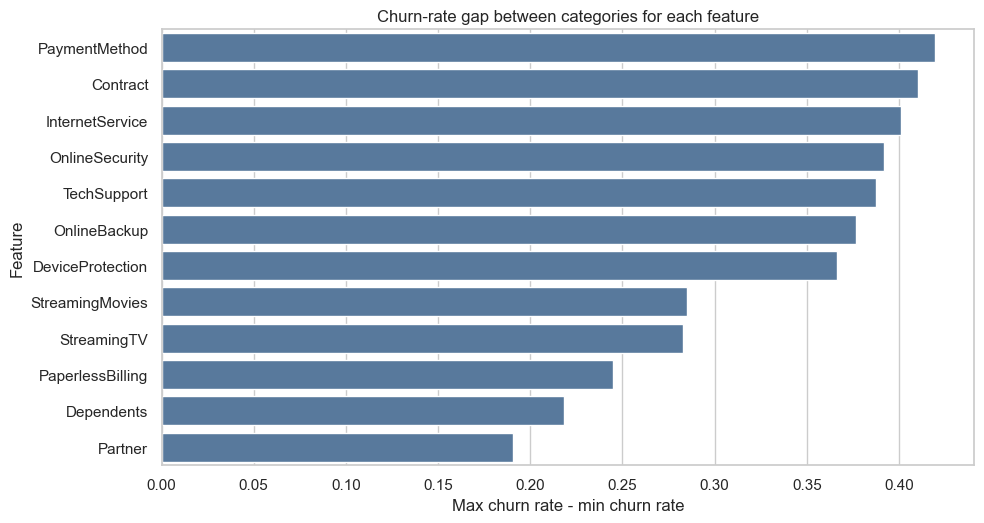

In [6]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
id_like_cols = [col for col in train.columns if col.lower() in {"id", "customerid", "customer_id"}]

target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

categorical_cols = [col for col in train.select_dtypes(exclude=np.number).columns if col not in id_like_cols + [target_col]]
tables = []
strength_rows = []
for col in categorical_cols:
    grouped = train.groupby(col, dropna=False)["_target"].agg(count="count", churn_rate="mean").reset_index()
    grouped["feature"] = col
    grouped = grouped.rename(columns={col: "category"})
    tables.append(grouped[["feature", "category", "count", "churn_rate"]])
    if grouped["churn_rate"].notna().sum() >= 2:
        strength_rows.append({
            "feature": col,
            "n_category": grouped["category"].nunique(dropna=False),
            "min_churn_rate": grouped["churn_rate"].min(),
            "max_churn_rate": grouped["churn_rate"].max(),
            "rate_gap": grouped["churn_rate"].max() - grouped["churn_rate"].min()
        })

if not tables:
    raise ValueError("No categorical features were found for analysis.")

category_summary = pd.concat(tables, ignore_index=True).sort_values(["feature", "churn_rate"], ascending=[True, False])
display(category_summary.head(80))

strength = pd.DataFrame(strength_rows).sort_values("rate_gap", ascending=False)
display(strength)

plot_df = strength.head(12)
plt.figure(figsize=(10, max(4, 0.45 * len(plot_df))))
ax = sns.barplot(data=plot_df, y="feature", x="rate_gap", color="#4C78A8")
ax.set_title("Churn-rate gap between categories for each feature")
ax.set_xlabel("Max churn rate - min churn rate")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


## 6. Contract, Internet, and Payment

`Contract`, `InternetService`, and `PaymentMethod` are worth checking more closely because they are easy to interpret and often strongly related to churn.

If groups like `Month-to-month`, `Fiber optic`, or `Electronic check` show much higher churn, they can become useful clues for feature engineering and for explaining the final model.


,feature,category,count,churn_rate
0,Contract,Month-to-month,298918,0.420543
1,Contract,One year,108333,0.057628
2,Contract,Two year,186943,0.009982
4,InternetService,Fiber optic,272386,0.415366
3,InternetService,DSL,181081,0.103064
5,InternetService,No,140727,0.014311
11,PaperlessBilling,Yes,365579,0.319387
10,PaperlessBilling,No,228615,0.074606
8,PaymentMethod,Electronic check,215372,0.489052
9,PaymentMethod,Mailed check,123757,0.079697


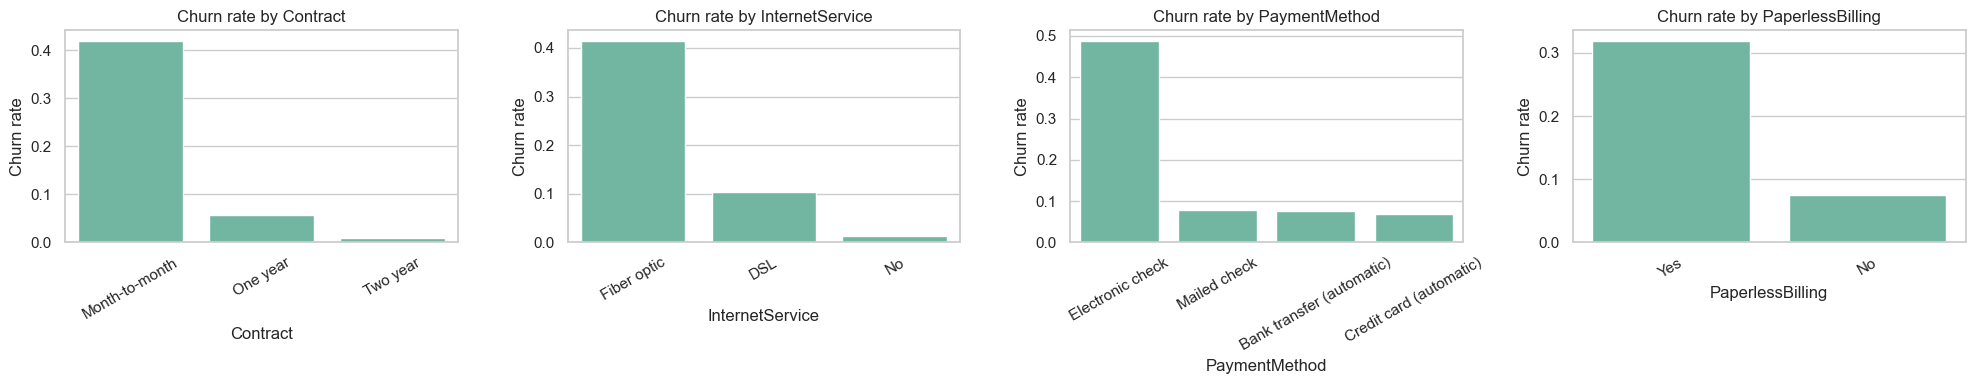

In [7]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

key_cols = [col for col in ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"] if col in train.columns]
if not key_cols:
    raise ValueError("No Contract/InternetService/PaymentMethod/PaperlessBilling columns were found in the data.")

summary_parts = []
for col in key_cols:
    part = train.groupby(col, dropna=False)["_target"].agg(count="count", churn_rate="mean").reset_index()
    part["feature"] = col
    part = part.rename(columns={col: "category"})
    summary_parts.append(part[["feature", "category", "count", "churn_rate"]])
display(pd.concat(summary_parts, ignore_index=True).sort_values(["feature", "churn_rate"], ascending=[True, False]))

fig, axes = plt.subplots(1, len(key_cols), figsize=(5 * len(key_cols), 4), squeeze=False)
for ax, col in zip(axes[0], key_cols):
    plot_df = train.groupby(col, dropna=False)["_target"].mean().reset_index().sort_values("_target", ascending=False)
    sns.barplot(data=plot_df, x=col, y="_target", ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 7. Tenure, Charges, and Churn

`tenure` and monthly cost are probably not independent. A new customer with high monthly charges may behave very differently from a long-term customer with the same charge level.

That is why I group both `tenure` and `MonthlyCharges`, then look at the churn rate for each combination. If one area of the heatmap is clearly risky, it may be useful to turn that pattern into a new feature.


,tenure_group,count,churn_rate
0,0-6,86374,0.543520
1,7-12,66272,0.429337
2,13-24,86024,0.285781
3,25-48,127988,0.170657
4,49+,227536,0.052704


,monthly_charge_group,count,churn_rate
0,"(18.249, 24.4]",118885,0.017227
1,"(24.4, 61.25]",118800,0.137466
2,"(61.25, 80.4]",118945,0.310438
3,"(80.4, 95.0]",118963,0.364155
4,"(95.0, 118.75]",118601,0.296726


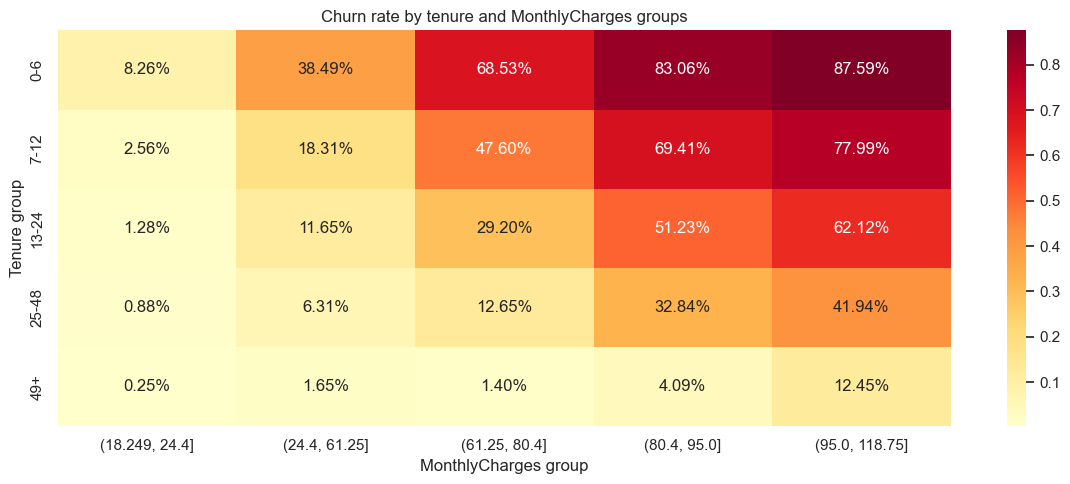

In [8]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")

if "tenure" not in train.columns or "MonthlyCharges" not in train.columns:
    raise ValueError("Both tenure and MonthlyCharges are required for this analysis.")

train["tenure_group"] = pd.cut(
    train["tenure"],
    bins=[-np.inf, 6, 12, 24, 48, np.inf],
    labels=["0-6", "7-12", "13-24", "25-48", "49+"]
)
train["monthly_charge_group"] = pd.qcut(train["MonthlyCharges"], q=5, duplicates="drop")

tenure_summary = train.groupby("tenure_group", observed=False)["_target"].agg(count="count", churn_rate="mean").reset_index()
charge_summary = train.groupby("monthly_charge_group", observed=False)["_target"].agg(count="count", churn_rate="mean").reset_index()
display(tenure_summary)
display(charge_summary)

pivot = train.pivot_table(index="tenure_group", columns="monthly_charge_group", values="_target", aggfunc="mean", observed=False)
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt=".2%", cmap="YlOrRd")
plt.title("Churn rate by tenure and MonthlyCharges groups")
plt.xlabel("MonthlyCharges group")
plt.ylabel("Tenure group")
plt.tight_layout()
plt.show()


## 8. Service Count and Churn

Looking at each service one by one is useful, but I also want a simple summary of how many services each customer uses. A customer with more active services may be more attached to the provider, or they may simply be paying more.

Here I create `service_count` and compare churn rates across service-count groups. If the pattern is clear, this could be a useful engineered feature.


,service_count,count,churn_rate
0,0,4767,0.346130
1,1,155347,0.110005
2,2,96933,0.302982
3,3,70160,0.375898
4,4,71076,0.374641
5,5,68148,0.282723
6,6,57163,0.178560
7,7,40014,0.064952
8,8,30586,0.020761


,service,churn_rate_yes,churn_rate_not_yes,gap_yes_minus_not_yes
6,StreamingTV,0.284660,0.184838,0.099821
7,StreamingMovies,0.283066,0.185608,0.097458
1,MultipleLines,0.277026,0.180712,0.096313
0,PhoneService,0.228920,0.168150,0.060771
4,DeviceProtection,0.182658,0.247802,-0.065144
3,OnlineBackup,0.167240,0.255375,-0.088134
5,TechSupport,0.096467,0.274658,-0.178191
2,OnlineSecurity,0.086821,0.277961,-0.191140


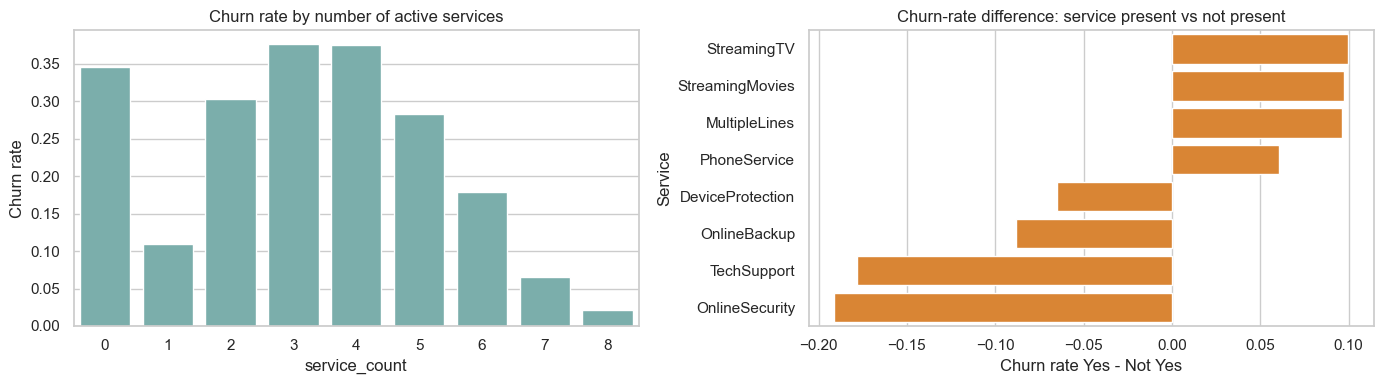

In [9]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

service_cols = [col for col in [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
] if col in train.columns]
if not service_cols:
    raise ValueError("No common service columns were found to create service_count.")

service_yes = train[service_cols].apply(lambda col: col.astype(str).str.strip().str.lower().eq("yes").astype(int))
train["service_count"] = service_yes.sum(axis=1)

service_count_summary = train.groupby("service_count")["_target"].agg(count="count", churn_rate="mean").reset_index()
display(service_count_summary)

service_effect_rows = []
for col in service_cols:
    has_service = train[col].astype(str).str.strip().str.lower().eq("yes")
    service_effect_rows.append({
        "service": col,
        "churn_rate_yes": train.loc[has_service, "_target"].mean(),
        "churn_rate_not_yes": train.loc[~has_service, "_target"].mean(),
        "gap_yes_minus_not_yes": train.loc[has_service, "_target"].mean() - train.loc[~has_service, "_target"].mean()
    })
service_effect = pd.DataFrame(service_effect_rows).sort_values("gap_yes_minus_not_yes", ascending=False)
display(service_effect)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=service_count_summary, x="service_count", y="churn_rate", ax=axes[0], color="#72B7B2")
axes[0].set_title("Churn rate by number of active services")
axes[0].set_ylabel("Churn rate")
sns.barplot(data=service_effect, y="service", x="gap_yes_minus_not_yes", ax=axes[1], color="#F58518")
axes[1].set_title("Churn-rate difference: service present vs not present")
axes[1].set_xlabel("Churn rate Yes - Not Yes")
axes[1].set_ylabel("Service")
plt.tight_layout()
plt.show()


## 9. Quick Signal Ranking

This is a quick way to rank which variables seem to carry signal. For numeric features, I use correlation with the encoded target. For categorical features, I use the gap between the highest and lowest category churn rates.

This is not the same as model feature importance, so I should not overstate it. A feature with low correlation can still matter if its effect is nonlinear or only appears through interactions with other features.


,corr_with_churn
tenure,-0.418453
MonthlyCharges,0.272997
SeniorCitizen,0.236362
TotalCharges,-0.218365


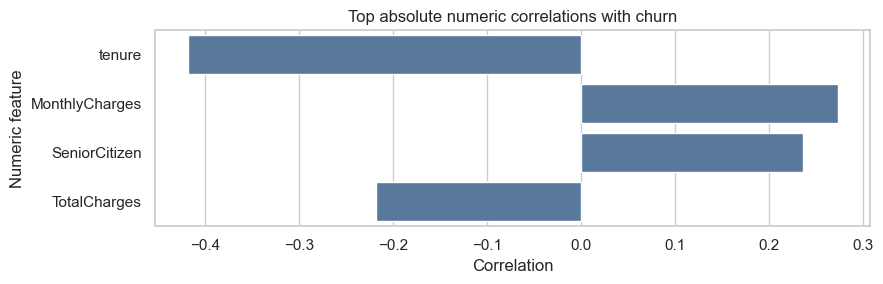

,feature,n_category,rate_gap,highest_churn_category,lowest_churn_category
14,PaymentMethod,4,0.419720,Electronic check,Credit card (automatic)
12,Contract,3,0.410562,Month-to-month,Two year
5,InternetService,3,0.401055,Fiber optic,No
6,OnlineSecurity,3,0.391822,No,No internet service
9,TechSupport,3,0.387309,No,No internet service
7,OnlineBackup,3,0.376715,No,No internet service
8,DeviceProtection,3,0.366318,No,No internet service
11,StreamingMovies,3,0.284988,No,No internet service
10,StreamingTV,3,0.283105,No,No internet service
13,PaperlessBilling,2,0.244781,Yes,No


In [10]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
id_like_cols = [col for col in train.columns if col.lower() in {"id", "customerid", "customer_id"}]
target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")

numeric_cols = [col for col in train.select_dtypes(include=np.number).columns if col not in id_like_cols + [target_col, "_target"]]
if numeric_cols:
    corr = train[numeric_cols + ["_target"]].corr(numeric_only=True)["_target"].drop("_target").sort_values(key=lambda s: s.abs(), ascending=False)
    display(corr.rename("corr_with_churn").to_frame())
    top_numeric = corr.head(10).index.tolist()
    plt.figure(figsize=(9, max(3, 0.4 * len(top_numeric))))
    sns.barplot(x=corr.loc[top_numeric].values, y=top_numeric, color="#4C78A8")
    plt.title("Top absolute numeric correlations with churn")
    plt.xlabel("Correlation")
    plt.ylabel("Numeric feature")
    plt.tight_layout()
    plt.show()

categorical_cols = [col for col in train.select_dtypes(exclude=np.number).columns if col not in id_like_cols + [target_col]]
cat_strength = []
for col in categorical_cols:
    grouped = train.groupby(col, dropna=False)["_target"].mean()
    if grouped.notna().sum() >= 2:
        cat_strength.append({
            "feature": col,
            "n_category": train[col].nunique(dropna=False),
            "rate_gap": grouped.max() - grouped.min(),
            "highest_churn_category": str(grouped.idxmax()),
            "lowest_churn_category": str(grouped.idxmin())
        })
cat_strength = pd.DataFrame(cat_strength).sort_values("rate_gap", ascending=False)
display(cat_strength.head(20))


## 10. Feature Ideas from EDA

After checking the patterns, I want to turn a few of them into candidate features. These are simple features based on patterns that are common in churn data: monthly contract, fiber optic service, electronic check payment, low tenure, high monthly charge, and risky combinations.

These features may or may not improve the final score, but they are easy to test. If a feature creates a clear churn-rate gap, I would keep it as a modeling candidate.


,feature,value,count,churn_rate
14,high_risk_profile,0.0,446041.0,0.096650
15,high_risk_profile,1.0,148153.0,0.612252
8,is_electronic_check,0.0,378822.0,0.075204
9,is_electronic_check,1.0,215372.0,0.489052
4,is_fiber_optic,0.0,321808.0,0.064253
5,is_fiber_optic,1.0,272386.0,0.415366
12,is_high_monthly_charge,0.0,296538.0,0.109318
13,is_high_monthly_charge,1.0,297656.0,0.340662
10,is_low_tenure,0.0,441548.0,0.132303
11,is_low_tenure,1.0,152646.0,0.493947


,feature,churn_rate_when_1_minus_0
7,high_risk_profile,0.515602
4,is_electronic_check,0.413847
0,is_month_to_month,0.393081
5,is_low_tenure,0.361644
2,is_fiber_optic,0.351114
6,is_high_monthly_charge,0.231344
3,is_no_internet,-0.276345
1,is_two_year,-0.314022


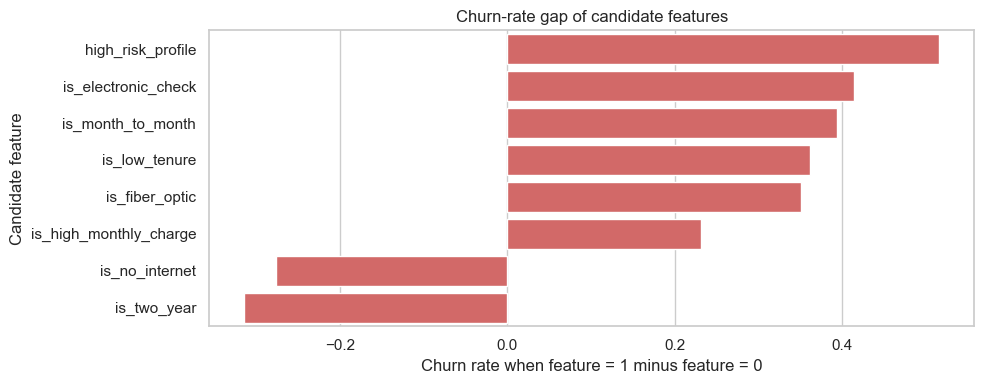

In [11]:
candidate_paths = [Path("../data/train.csv"), Path("data/train.csv")]
train_path = next((path for path in candidate_paths if path.exists()), None)
if train_path is None:
    raise FileNotFoundError("train.csv was not found. Please place the data at data/train.csv as described in README.")

train = pd.read_csv(train_path)
target_candidates = [col for col in ["Churn", "churn", "target", "Target"] if col in train.columns]
target_col = target_candidates[0] if target_candidates else train.columns[-1]
target_numeric = train[target_col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0, "1": 1, "0": 0, "true": 1, "false": 0})
if target_numeric.isna().all():
    target_numeric = pd.to_numeric(train[target_col], errors="coerce")
train = train.assign(_target=target_numeric)

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in train.columns:
        train[col] = pd.to_numeric(train[col], errors="coerce")

feature_cols = []
if "Contract" in train.columns:
    train["is_month_to_month"] = train["Contract"].astype(str).eq("Month-to-month").astype(int)
    train["is_two_year"] = train["Contract"].astype(str).eq("Two year").astype(int)
    feature_cols += ["is_month_to_month", "is_two_year"]
if "InternetService" in train.columns:
    train["is_fiber_optic"] = train["InternetService"].astype(str).eq("Fiber optic").astype(int)
    train["is_no_internet"] = train["InternetService"].astype(str).eq("No").astype(int)
    feature_cols += ["is_fiber_optic", "is_no_internet"]
if "PaymentMethod" in train.columns:
    train["is_electronic_check"] = train["PaymentMethod"].astype(str).str.contains("Electronic check", case=False, na=False).astype(int)
    feature_cols.append("is_electronic_check")
if "tenure" in train.columns:
    train["is_low_tenure"] = (train["tenure"] <= 12).astype(int)
    feature_cols.append("is_low_tenure")
if "MonthlyCharges" in train.columns:
    monthly_threshold = train["MonthlyCharges"].median()
    train["is_high_monthly_charge"] = (train["MonthlyCharges"] >= monthly_threshold).astype(int)
    feature_cols.append("is_high_monthly_charge")
if "TotalCharges" in train.columns and "tenure" in train.columns:
    train["charge_per_tenure"] = train["TotalCharges"] / train["tenure"].replace(0, np.nan)
    feature_cols.append("charge_per_tenure")
if {"Contract", "InternetService", "PaymentMethod"}.issubset(train.columns):
    train["high_risk_profile"] = (
        train["Contract"].astype(str).eq("Month-to-month")
        & train["InternetService"].astype(str).eq("Fiber optic")
        & train["PaymentMethod"].astype(str).str.contains("Electronic check", case=False, na=False)
    ).astype(int)
    feature_cols.append("high_risk_profile")

if not feature_cols:
    raise ValueError("No candidate features could be created because common churn columns are missing.")

binary_features = [col for col in feature_cols if train[col].dropna().nunique() <= 2]
summary_rows = []
for col in binary_features:
    grouped = train.groupby(col)["_target"].agg(count="count", churn_rate="mean").reset_index()
    for _, row in grouped.iterrows():
        summary_rows.append({"feature": col, "value": row[col], "count": row["count"], "churn_rate": row["churn_rate"]})
binary_summary = pd.DataFrame(summary_rows)
display(binary_summary.sort_values(["feature", "value"]))

gap_rows = []
for col in binary_features:
    grouped = train.groupby(col)["_target"].mean()
    if set(grouped.index) >= {0, 1}:
        gap_rows.append({"feature": col, "churn_rate_when_1_minus_0": grouped.loc[1] - grouped.loc[0]})
gap_df = pd.DataFrame(gap_rows).sort_values("churn_rate_when_1_minus_0", ascending=False)
display(gap_df)

if not gap_df.empty:
    plt.figure(figsize=(10, max(4, 0.45 * len(gap_df))))
    sns.barplot(data=gap_df, y="feature", x="churn_rate_when_1_minus_0", color="#E45756")
    plt.title("Churn-rate gap of candidate features")
    plt.xlabel("Churn rate when feature = 1 minus feature = 0")
    plt.ylabel("Candidate feature")
    plt.tight_layout()
    plt.show()


## Notes for Final Write-Up

After running this with the real data, I should add short comments under the most important charts. The comments should focus on clear patterns, such as high-risk customer groups, shifted distributions, and feature ideas worth testing. I should avoid claiming causality because this EDA only shows patterns and correlations.
